# 🎬 Movie Dataset Analysis


---
## ⚙️ Setup: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make plots look nicer by using runtime configuration parameters
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100 # Dots per inch, It controls image quality/resolution.

---
## Task 1: Explore the Dataset

In [2]:
# Load the dataset
movies = pd.read_excel('movies_updated.xlsx')

# Fix the messy runtime column name
movies.rename(columns={'runtime,,': 'runtime'}, inplace=True)

# Fix runtime values (they have trailing commas like '146.0,')
movies['runtime'] = movies['runtime'].astype(str).str.replace(',', '').str.strip()
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce') #converts back to numbers and changes invalid value to NaN

In [3]:
movies.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,98.0


In [4]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      4000 non-null   object 
 1   rating    3960 non-null   str    
 2   genre     4000 non-null   str    
 3   year      4000 non-null   int64  
 4   released  4000 non-null   str    
 5   score     4000 non-null   float64
 6   votes     4000 non-null   int64  
 7   director  4000 non-null   str    
 8   writer    3999 non-null   str    
 9   star      3999 non-null   str    
 10  country   4000 non-null   str    
 11  budget    4000 non-null   int64  
 12  gross     3831 non-null   float64
 13  company   3990 non-null   str    
 14  runtime   4000 non-null   float64
dtypes: float64(3), int64(3), object(1), str(8)
memory usage: 468.9+ KB


In [5]:
movies.describe()

,year,score,votes,budget,gross,runtime
count,4000.000000,4000.000000,4.000000e+03,4.000000e+03,3.831000e+03,4000.000000
mean,1991.191500,6.321950,5.449450e+04,1.542740e+07,4.172202e+07,105.711750
std,5.934529,0.977101,1.427738e+05,2.248639e+07,9.259504e+07,18.470556
min,1980.000000,2.200000,5.100000e+01,0.000000e+00,3.090000e+02,55.000000
25%,1986.000000,5.700000,4.300000e+03,0.000000e+00,2.835743e+06,94.000000
50%,1991.000000,6.400000,1.300000e+04,7.000000e+06,1.183822e+07,102.000000
75%,1996.000000,7.000000,4.500000e+04,2.100000e+07,3.560495e+07,114.000000
max,2001.000000,9.300000,2.400000e+06,2.000000e+08,2.201647e+09,357.000000


In [6]:
# Q1: How many movies?
print(f"Total movies in the dataset: {len(movies)}")

# Q2: Numerical columns
print("\nNumerical columns:", movies.select_dtypes(include='number').columns.tolist())

# Q3: Categorical columns
print("Categorical columns:", movies.select_dtypes(include='object').columns.tolist())

Total movies in the dataset: 4000

Numerical columns: ['year', 'score', 'votes', 'budget', 'gross', 'runtime']
Categorical columns: ['name', 'rating', 'genre', 'released', 'director', 'writer', 'star', 'country', 'company']


### ✅ Task 1 Answers
1. **4,000 movies** in the dataset
2. **Numerical columns**: year, score, votes, budget, gross, runtime
3. **Categorical columns**: name, rating, genre, released, director, writer, star, country, company

---
## Task 2: Number of Movies Released Each Year

In [7]:
# Count movies per year
movies_per_year = movies.groupby('year')['name'].count().reset_index()
movies_per_year.columns = ['year', 'count']

print("Movies per year:")
print(movies_per_year)
print(f"\nYear with most movies: {movies_per_year.loc[movies_per_year['count'].idxmax(), 'year']} "
      f"({movies_per_year['count'].max()} movies)")

Movies per year:
    year  count
0   1980     92
1   1981    113
2   1982    126
3   1983    144
4   1984    168
5   1985    200
6   1986    200
7   1987    200
8   1988    200
9   1989    200
10  1990    200
11  1991    200
12  1992    200
13  1993    200
14  1994    200
15  1995    200
16  1996    200
17  1997    200
18  1998    200
19  1999    200
20  2000    200
21  2001    157

Year with most movies: 1985 (200 movies)


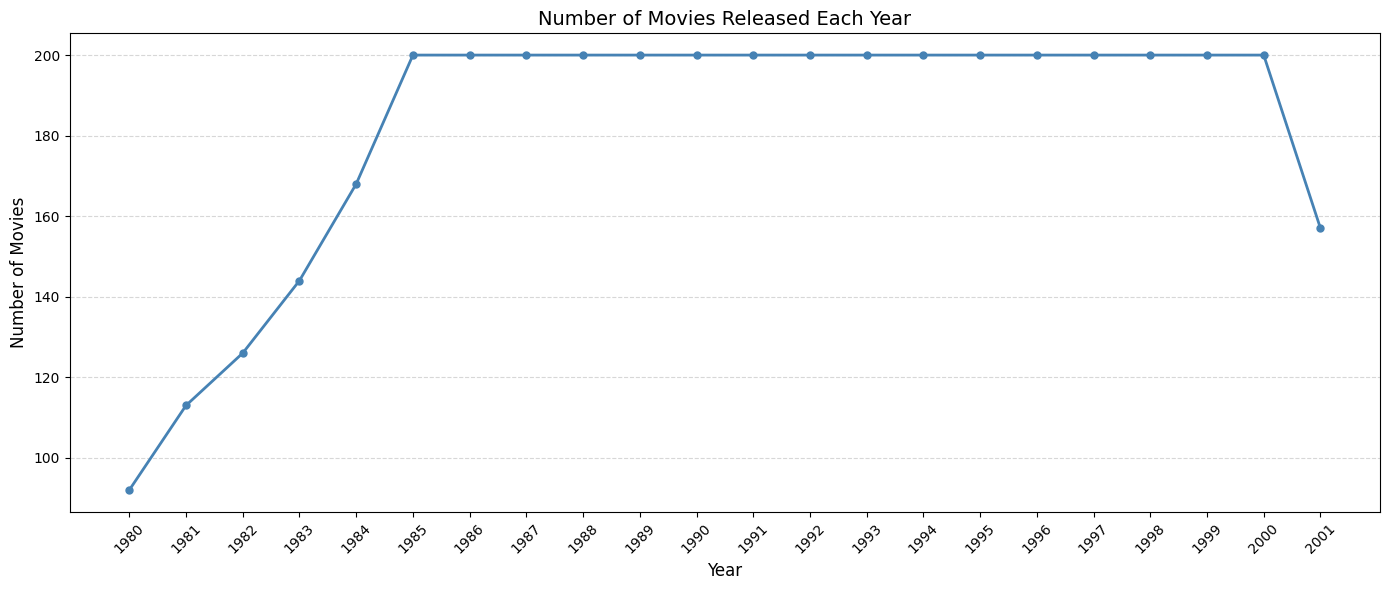

In [8]:
# Line Plot
plt.figure(figsize=(14, 6))
plt.plot(movies_per_year['year'], movies_per_year['count'],
         marker='o', linewidth=2, color='steelblue', markersize=5)

plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.xticks(movies_per_year['year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()#Auto-fixes spacing so rotated tick labels or axis labels don't get cut off at the edges.
plt.savefig('task2_movies_per_year.png', bbox_inches='tight')
plt.show()

### ✅ Task 2 Answers
1. **1985** had the most movies (200)
2. The trend is **not strictly increasing** — it peaks around the mid-80s, dips, then rises again in the 90s
3. The trend shows **fluctuation** throughout the 1980–2001 period with a general rise toward the late 1990s

---
## Task 3: Top 10 Movie Genres

In [9]:
# Top 10 genres by count
top10_genres = movies['genre'].value_counts().head(10)
print(top10_genres)

genre
Comedy       1355
Drama         807
Action        775
Crime         302
Adventure     231
Biography     175
Horror        158
Animation     113
Fantasy        33
Mystery        13
Name: count, dtype: int64


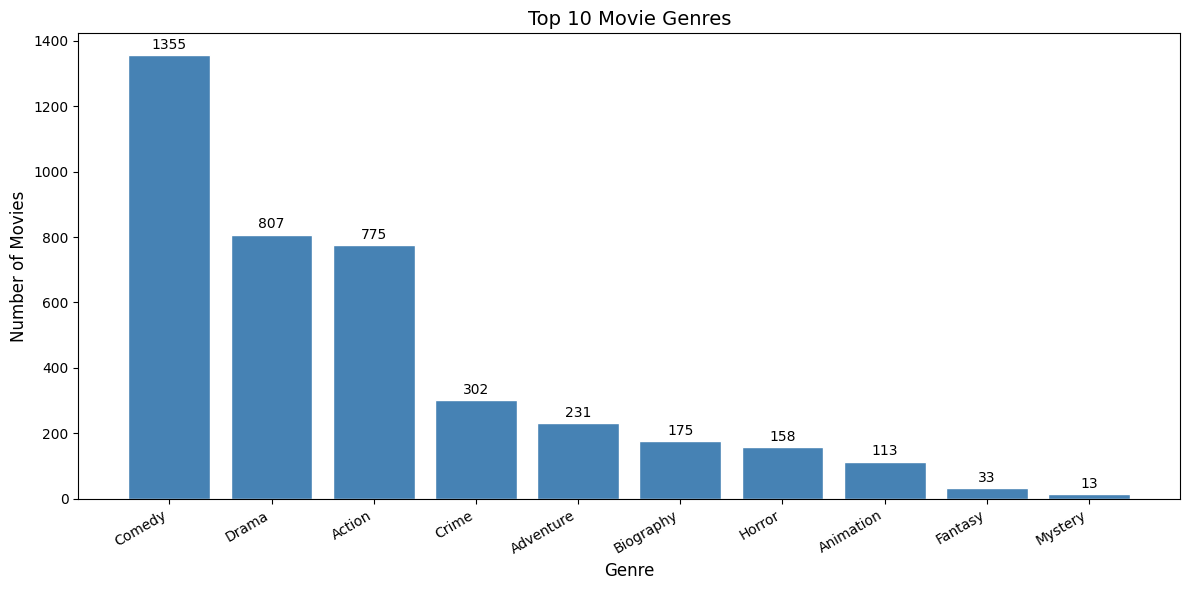

In [10]:
# Vertical Bar Chart
plt.figure(figsize=(12, 6))
bars = plt.bar(top10_genres.index, top10_genres.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=10)

plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task3_top10_genres.png', bbox_inches='tight')
plt.show()

### ✅ Task 3 Answers
1. **Comedy** has the most movies (1,355)
2. **Mystery** has the fewest among the top 10 (13)
3. A bar chart is suitable because we are **comparing discrete categories** (genres), making it easy to see differences in count at a glance

---
## Task 4: Top 10 Directors

In [11]:
# Top 10 directors
top10_directors = movies['director'].value_counts().head(10)
print(top10_directors)

director
Woody Allen         22
Clint Eastwood      16
Directors           16
Barry Levinson      16
Walter Hill         15
Sidney Lumet        15
Joel Schumacher     15
John Carpenter      14
Steven Spielberg    14
Ron Howard          14
Name: count, dtype: int64


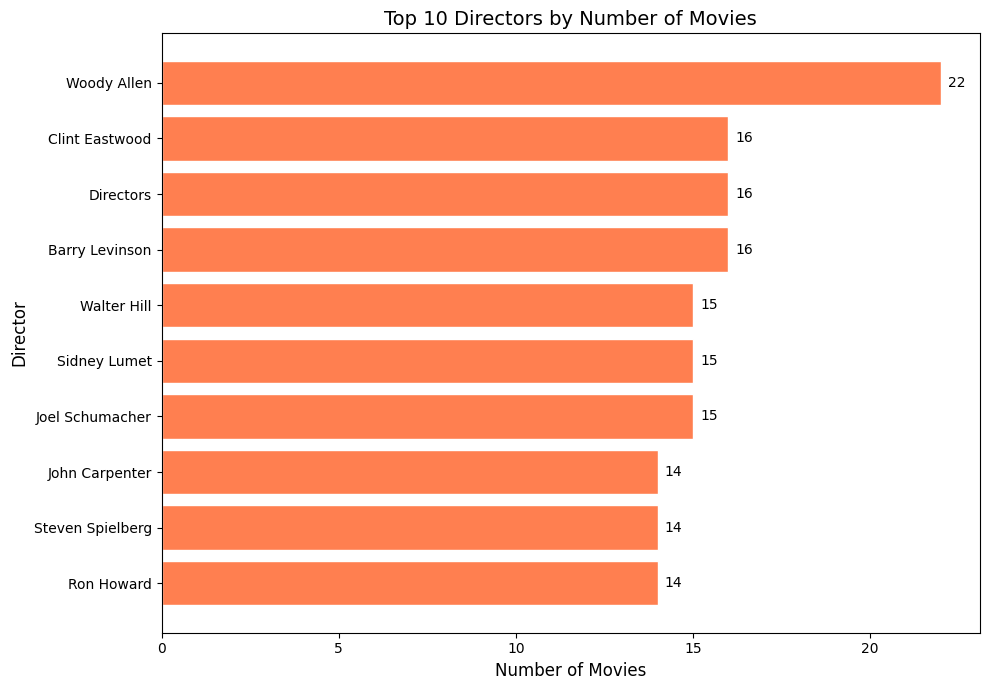

In [12]:
# Horizontal Bar Chart (barh)
plt.figure(figsize=(10, 7))
bars = plt.barh(top10_directors.index[::-1], top10_directors.values[::-1],
                color='coral', edgecolor='white')

# Add count labels at end of each bar
for bar in bars:
    plt.text(bar.get_width() + 0.2,
             bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())),
             ha='left', va='center', fontsize=10)

plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.tight_layout()
plt.savefig('task4_top10_directors.png', bbox_inches='tight')
plt.show()

### ✅ Task 4 Answers
1. **Woody Allen** produced the most movies (22)
2. A horizontal bar chart is better here because **director names are long strings** — they are readable on the y-axis instead of being cramped or rotated on the x-axis

---
## Task 5: Distribution of Movie Ratings (Score)

Mean score: 6.32
Most common score range: 6.0 – 7.0


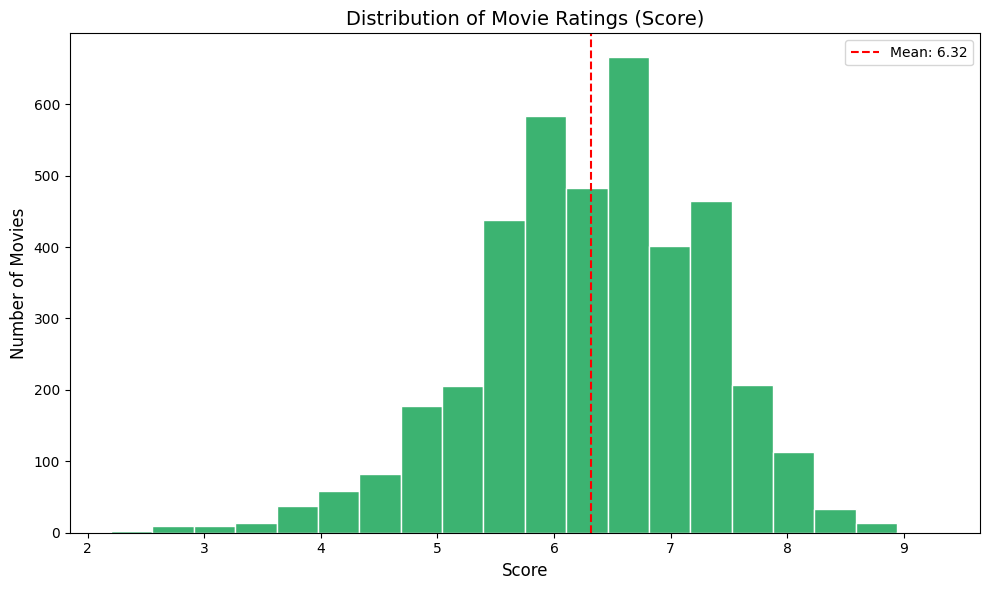

In [13]:
# Histogram of scores
plt.figure(figsize=(10, 6))
plt.hist(movies['score'], bins=20, color='mediumseagreen', edgecolor='white')

plt.title('Distribution of Movie Ratings (Score)')
plt.xlabel('Score')
plt.ylabel('Number of Movies')
plt.axvline(movies['score'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean: {movies['score'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('task5_score_distribution.png', bbox_inches='tight')
plt.show()

print(f"Mean score: {movies['score'].mean():.2f}")
print(f"Most common score range: 6.0 – 7.0")

### ✅ Task 5 Answers
1. The **6.0–7.0** score range contains the largest number of movies
2. Most movies score **around 6–7** — they are moderately rated, not extremely high
3. **Low-rated movies (below 4) are rare** — very few movies score that low
4. The histogram shows a **roughly bell-shaped (normal) distribution** skewed slightly to the right, centered around 6.3

---
## Task 6: Average Movie Score by Genre

In [14]:
# Average score per genre, sorted descending
avg_score_genre = movies.groupby('genre')['score'].mean().sort_values(ascending=False)
print(avg_score_genre)

genre
History      8.300000
Music        7.200000
Biography    7.052000
Animation    6.883186
Drama        6.673606
Crime        6.645033
Family       6.550000
Mystery      6.500000
Romance      6.400000
Comedy       6.179410
Adventure    6.151948
Fantasy      6.024242
Action       6.014968
Sci-Fi       5.983333
Thriller     5.890909
Horror       5.744304
Western      5.666667
Name: score, dtype: float64


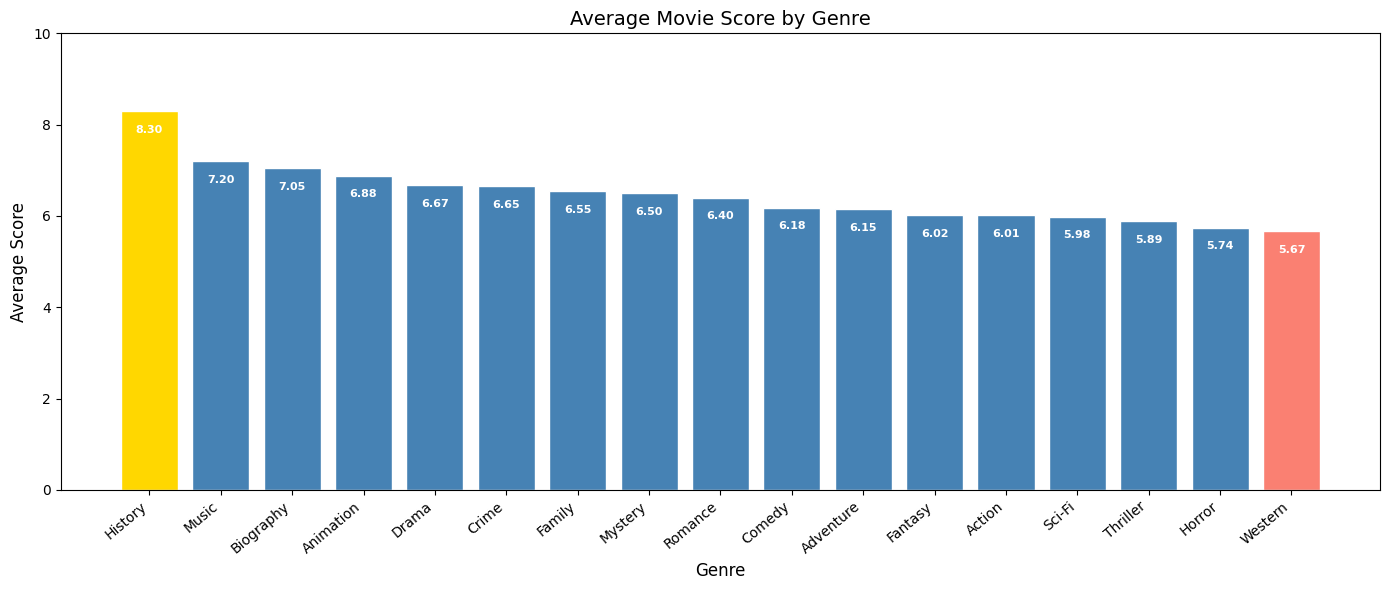

In [15]:
# Bar chart of avg score by genre
plt.figure(figsize=(14, 6))
colors = ['gold' if s == avg_score_genre.max() else
          'salmon' if s == avg_score_genre.min() else
          'steelblue' for s in avg_score_genre.values]

bars = plt.bar(avg_score_genre.index, avg_score_genre.values,
               color=colors, edgecolor='white')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 0.3,
             f"{bar.get_height():.2f}",
             ha='center', va='top', fontsize=8, color='white', fontweight='bold')

plt.title('Average Movie Score by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.ylim(0, 10)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('task6_avg_score_genre.png', bbox_inches='tight')
plt.show()

### ✅ Task 6 Answers
1. **History** has the highest average score (8.30)
2. **Western** has the lowest average score (5.67)
3. **No** — the most popular genre (Comedy) does not have the highest average rating. History and Biography rank highest despite being less common

---
## Task 7: Top 10 Highest Grossing Movies

In [16]:
# Top 10 by gross revenue (drop rows where gross is missing)
top10_gross = (movies.dropna(subset=['gross'])
               .nlargest(10, 'gross')[['name', 'gross']]
               .reset_index(drop=True))
print(top10_gross)

                                                name         gross
0                                            Titanic  2.201647e+09
1                                      The Lion King  1.083721e+09
2                                      Jurassic Park  1.033928e+09
3          Star Wars: Episode I - The Phantom Menace  1.027083e+09
4              Harry Potter and the Sorcerer's Stone  1.006968e+09
5  The Lord of the Rings: The Fellowship of the Ring  8.976901e+08
6                                   Independence Day  8.174009e+08
7                         E.T. the Extra-Terrestrial  7.929106e+08
8                                       Forrest Gump  6.782261e+08
9                                    The Sixth Sense  6.728063e+08


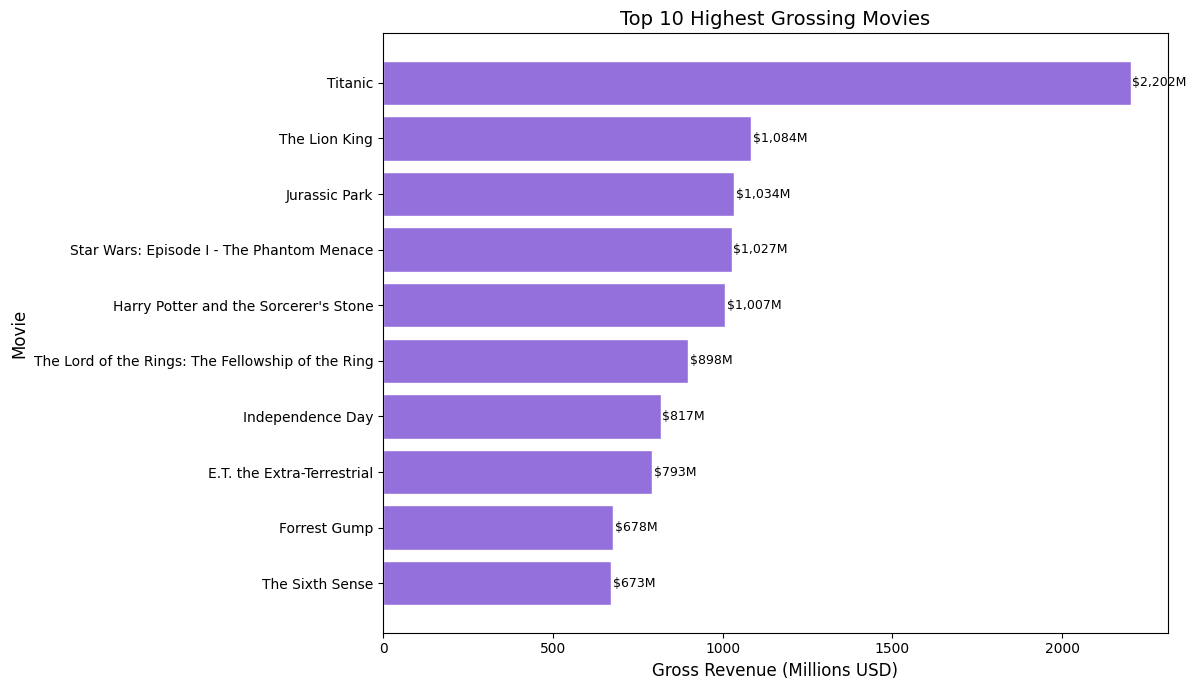

In [17]:
# Horizontal bar chart
plt.figure(figsize=(12, 7))
bars = plt.barh(top10_gross['name'][::-1], top10_gross['gross'][::-1] / 1e6,
                color='mediumpurple', edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height() / 2,
             f"${bar.get_width():,.0f}M",
             ha='left', va='center', fontsize=9)

plt.title('Top 10 Highest Grossing Movies')
plt.xlabel('Gross Revenue (Millions USD)')
plt.ylabel('Movie')
plt.tight_layout()
plt.savefig('task7_top10_gross.png', bbox_inches='tight')
plt.show()

### ✅ Task 7 Answers
1. **Titanic** earned the highest revenue (~$2.2 billion)
2. **Yes** — Titanic earned roughly **twice** as much as the second-highest (The Lion King)
3. The top 5 movies all crossed $1 billion. The list includes beloved franchises (Star Wars, Harry Potter, Jurassic Park), showing that **family-friendly blockbusters dominate** box office revenue

---
## 📝 Final Storytelling Report

> *As a data analyst working for a movie production company, here are my key findings from the 1980–2001 movie dataset:*
>
> The dataset contains **4,000 movies** spanning 21 years. **Comedy** is by far the most common genre (1,355 films), followed by Drama and Action — suggesting these genres are the safest bet for consistent production volume. However, genre popularity does not equal quality: **History and Biography** genres earn the highest average audience scores, while Comedy scores near the middle. Most movies cluster around a **score of 6–7 out of 10**, indicating audiences rate most films as average-to-good, with truly low-rated films being rare. Movie production **fluctuated** between 1980 and 2001 rather than growing steadily, peaking mid-1980s and again in the late 1990s. In terms of revenue, **Titanic dominates** all others with $2.2 billion gross — nearly double its closest competitors — and the top earners are mostly **adventure and family films**.
>
> **Recommendations for the studio:** Invest in **Biography and Drama** films for critical acclaim and audience satisfaction. For maximum box-office return, target **adventure and family-friendly blockbusters**. Avoid over-indexing on Comedy volume alone, as it does not translate to the highest ratings or revenues.